In [3]:
# 加载所需的函数
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")     # 忽略所有警告

# 加载iris数据
iris = load_iris()
iris_data = iris.data
iris_target = iris.target

# 划分训练集和测试集
iris_data_train, iris_data_test, iris_target_train, iris_target_test = \
    train_test_split(iris_data, iris_target, test_size=0.2, random_state=123)

# 建立神经网络模型
# 双隐层网络结构，第一层隐层有20个神经元，第二层隐层有25个神经元
model_network = MLPClassifier(hidden_layer_sizes=(20, 25), random_state=123)
model_network.fit(iris_data_train, iris_target_train)
print("建立的神经网络模型为：\n", model_network)

# 预测测试集结果
iris_target_test_pred = model_network.predict(iris_data_test)
print('预测前20个结果为：\n', iris_target_test_pred[:20])
print('实际前20个结果为：\n', iris_target_test[:20])

# 评价分类模型的指标
print('神经网络模型预测的准确率为：\n', accuracy_score(iris_target_test, iris_target_test_pred))
# 对于多分类任务，precision、recall、f1_score需要指定average参数，这里以macro为例
print('神经网络模型预测的精确率为：\n', precision_score(iris_target_test, iris_target_test_pred, average='macro'))
print('神经网络模型预测的召回率为：\n', recall_score(iris_target_test, iris_target_test_pred, average='macro'))
print('神经网络模型预测的F1值为：\n', f1_score(iris_target_test, iris_target_test_pred, average='macro'))


建立的神经网络模型为：
 MLPClassifier(hidden_layer_sizes=(20, 25), random_state=123)
预测前20个结果为：
 [2 2 2 1 0 2 1 0 0 1 2 0 1 2 2 2 0 0 1 0]
实际前20个结果为：
 [1 2 2 1 0 2 1 0 0 1 2 0 1 2 2 2 0 0 1 0]
神经网络模型预测的准确率为：
 0.9666666666666667
神经网络模型预测的精确率为：
 0.9722222222222222
神经网络模型预测的召回率为：
 0.9444444444444445
神经网络模型预测的F1值为：
 0.9552042160737813



==== ROC曲线与AUC评价指标 ====
类别 0 的 AUC 值为：1.0000
类别 1 的 AUC 值为：0.9861
类别 2 的 AUC 值为：0.9904
Macro-average AUC 值为：0.9946


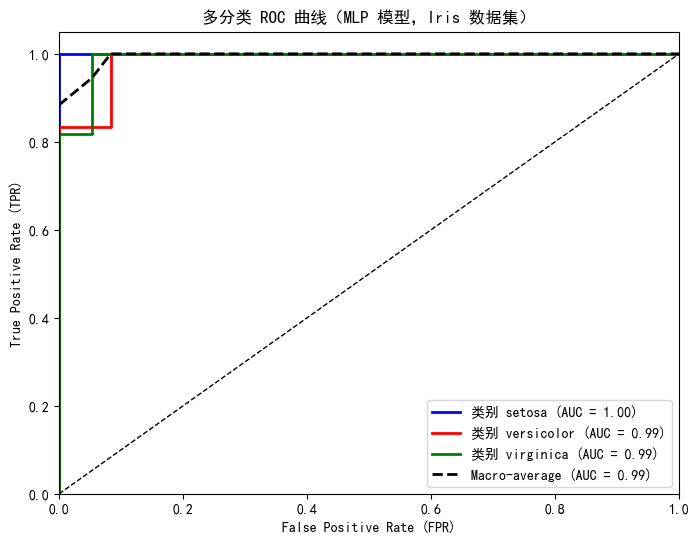

In [5]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 获取模型对测试集的预测概率（关键步骤！）
y_score = model_network.predict_proba(iris_data_test)  # 形状：[n_samples, n_classes]

# 将测试集的真实标签进行 one-hot 编码（二值化，为了逐类计算 ROC）
n_classes = len(np.unique(iris_target))
y_test_bin = label_binarize(iris_target_test, classes=np.arange(n_classes))

# 计算每个类别的 ROC 曲线和 AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 计算 Macro-average ROC 曲线和 AUC
# 先插值求每个类的平均 TPR
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# 打印各个类别及 Macro AUC 值
print("\n==== ROC曲线与AUC评价指标 ====")
for i in range(n_classes):
    print(f"类别 {i} 的 AUC 值为：{roc_auc[i]:.4f}")
print(f"Macro-average AUC 值为：{roc_auc['macro']:.4f}")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['simhei']
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号


# 绘制 ROC 曲线图
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
class_names = iris.target_names if hasattr(iris, 'target_names') else [f'Class {i}' for i in range(n_classes)]

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'类别 {class_names[i]} (AUC = {roc_auc[i]:.2f})')

# 绘制 Macro-average ROC 曲线
plt.plot(fpr["macro"], tpr["macro"],
         color='black', linestyle='--', linewidth=2,
         label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})')

# 绘制对角线（随机猜测的 ROC）
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('多分类 ROC 曲线（MLP 模型，Iris 数据集）')
plt.legend(loc="lower right")
plt.show()